<a href="https://colab.research.google.com/github/cq88661/232e-proj1/blob/main/232eproj1(1_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.1(a)**

In [ ]:
# !pip install python-igraph numpy matplotlib pycairo


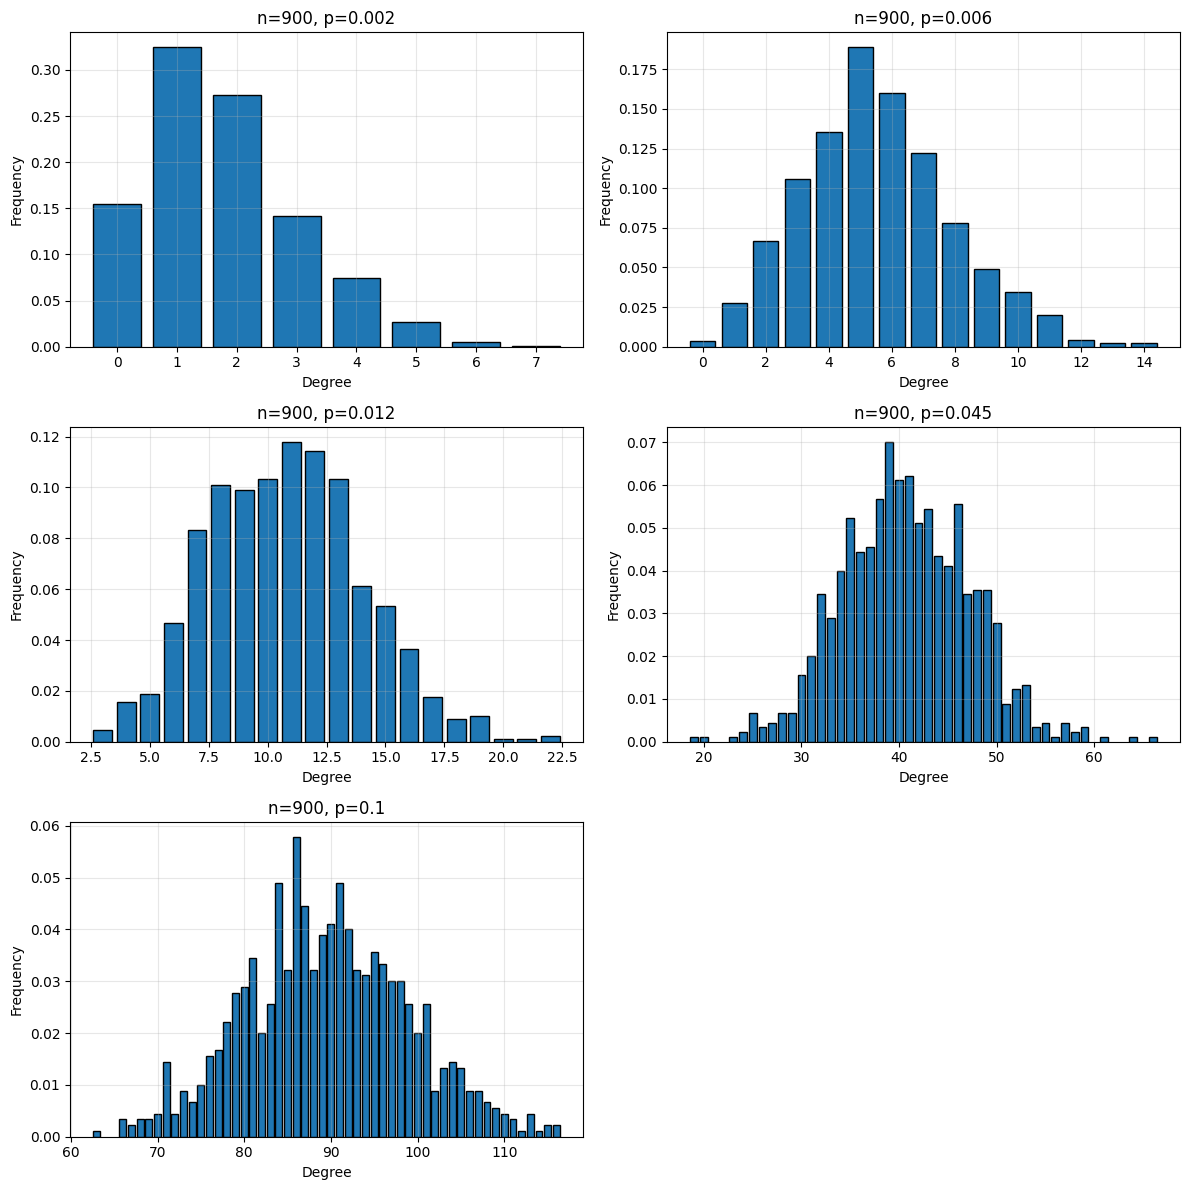

       p  Connected  Nodes  Edges  Empirical Mean  Theoretical Mean  \
0  0.002      False    900    794        1.764444             1.798   
1  0.006      False    900   2484        5.520000             5.394   
2  0.012       True    900   4845       10.766667            10.788   
3  0.045       True    900  18315       40.700000            40.455   
4  0.100       True    900  40272       89.493333            89.900   

   Empirical Variance  Theoretical Variance  
0            1.682291              1.794404  
1            5.667378              5.361636  
2           10.614444             10.658544  
3           43.178889             38.634525  
4           88.065511             80.910000  


In [9]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
%matplotlib inline
n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]

results = []

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, p in enumerate(p_values):
    # Create ER graph
    g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)

    # Degree distribution
    deg = g.degree()
    counts = Counter(deg)
    k_vals = sorted(counts.keys())
    freq = [counts[k] / g.vcount() for k in k_vals]

    axes[i].bar(k_vals, freq, edgecolor='black')
    axes[i].set_title(f'n={n}, p={p}')
    axes[i].set_xlabel('Degree')
    axes[i].set_ylabel('Frequency')

    # Empirical statistics
    empirical_mean = np.mean(deg)
    empirical_variance = np.var(deg)

    # Theoretical statistics
    theoretical_mean = (n - 1) * p
    theoretical_variance = (n - 1) * p * (1 - p)

    results.append({
        'p': p,
        'Connected': g.is_connected(),
        'Nodes': g.vcount(),
        'Edges': g.ecount(),
        'Empirical Mean': empirical_mean,
        'Theoretical Mean': theoretical_mean,
        'Empirical Variance': empirical_variance,
        'Theoretical Variance': theoretical_variance
    })

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

# Results table
df = pd.DataFrame(results)
print(df)

**Explanation**

The observed degree distribution is theoretically a binomial distribution.

For smaller values of p, the degree distribution appears right-skewed and resembles a Poisson or exponential-like distribution.

As p increases, the mean degree np becomes larger, and the binomial distribution approaches a Gaussian (normal) distribution by the central limit theorem.

From the above results, we can tell the empirical means and variances closely match the theoretical values predicted by the binomial distribution.


**1.1(b)**

In [ ]:
import networkx as nx
import numpy as np
import pandas as pd

n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]
num_trials = 100
seed_base = 42

results = []

for p in p_values:
    connected_count = 0

    for trial in range(num_trials):
        G = nx.gnp_random_graph(n, p, seed=seed_base + trial)
        if nx.is_connected(G):
            connected_count += 1

    prob_connected = connected_count / num_trials

    G_instance = nx.gnp_random_graph(n, p, seed=seed_base + 1000)

    if nx.is_connected(G_instance):
        gcc = G_instance
        gcc_size = G_instance.number_of_nodes()
        gcc_diameter = nx.diameter(gcc)
        connected_status = True
    else:
        connected_status = False

        components = list(nx.connected_components(G_instance))

        gcc_nodes = max(components, key=len)
        gcc = G_instance.subgraph(gcc_nodes).copy()
        gcc_size = gcc.number_of_nodes()
        gcc_diameter = nx.diameter(gcc)

    results.append({
        "p": p,
        "Estimated P(connected)": prob_connected,
        "Example network connected?": connected_status,
        "GCC size": gcc_size,
        "GCC diameter": gcc_diameter
    })

df = pd.DataFrame(results)

print(df)

       p  Estimated P(connected)  Example network connected?  GCC size  \
0  0.002                    0.00                       False       654   
1  0.006                    0.05                       False       894   
2  0.012                    0.99                        True       900   
3  0.045                    1.00                        True       900   
4  0.100                    1.00                        True       900   

   GCC diameter  
0            24  
1             8  
2             6  
3             3  
4             3  


In [10]:
import igraph as ig
import numpy as np
import pandas as pd
import random

n = 900
p_values = [0.002, 0.006, 0.012, 0.045, 0.1]
num_trials = 100
seed_base = 42

results = []

for p in p_values:
    connected_count = 0

    for trial in range(num_trials):
        random.seed(seed_base + trial)
        g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)

        if g.is_connected():
            connected_count += 1

    prob_connected = connected_count / num_trials

    random.seed(seed_base + 1000)
    g_instance = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)

    if g_instance.is_connected():
        gcc = g_instance
        gcc_size = g_instance.vcount()
        gcc_diameter = gcc.diameter()
        connected_status = True
    else:
        connected_status = False
        gcc = g_instance.components().giant()
        gcc_size = gcc.vcount()
        gcc_diameter = gcc.diameter()

    results.append({
        "p": p,
        "Estimated P(connected)": prob_connected,
        "Example network connected?": connected_status,
        "GCC size": gcc_size,
        "GCC diameter": gcc_diameter
    })

df = pd.DataFrame(results)
print(df)

       p  Estimated P(connected)  Example network connected?  GCC size  \
0  0.002                    0.00                       False       637   
1  0.006                    0.01                       False       898   
2  0.012                    1.00                        True       900   
3  0.045                    1.00                        True       900   
4  0.100                    1.00                        True       900   

   GCC diameter  
0            25  
1             8  
2             5  
3             3  
4             3  


For p = 0.002, the network is not connected. The GCC has size 637 and diameter 25.

For p = 0.006, the network is also not connected. The GCC has size 898 and diameter 8.

For p = 0.012, 0.045, and 0.1, the network is connected, so the GCC is the entire network of size 900. The corresponding diameters are 5, 3, and 3, respectively.

**1.1(c)**

Theoretical giant-component threshold ~ 1/n = 0.001111
Theoretical connectivity threshold ~ ln(n)/n = 0.007558


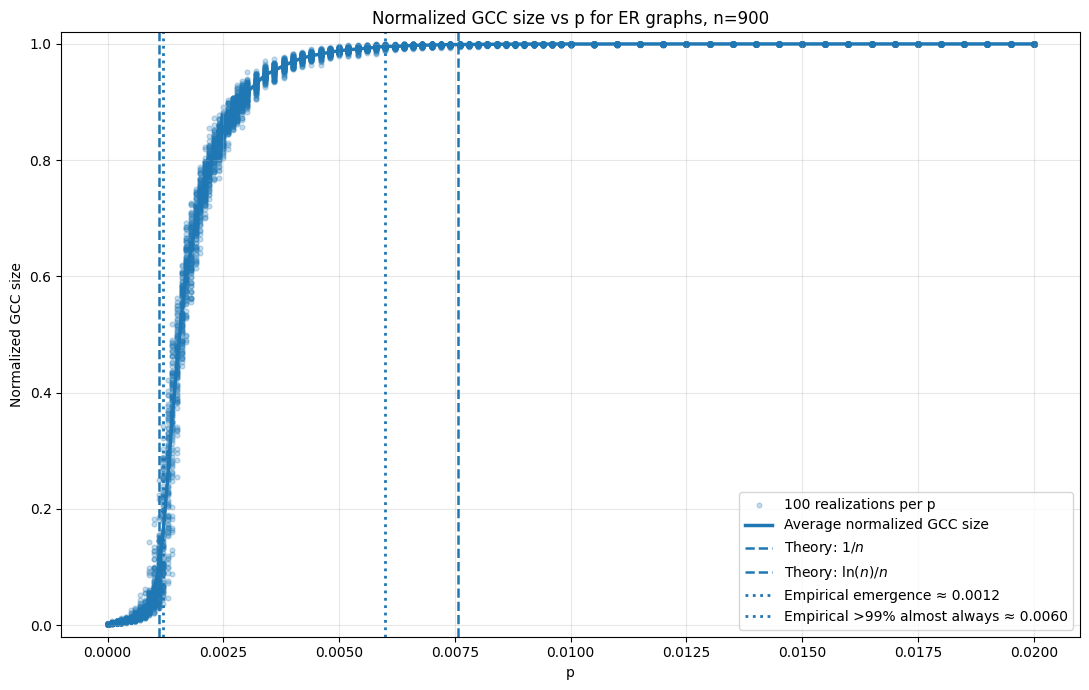


--- Empirical threshold estimates ---
Giant component emergence threshold (empirical) ≈ 0.001200
GCC > 99% in almost every experiment ≈ 0.006000

--- Theory comparison ---
Theoretical giant-component threshold ~ 1/n = 0.001111
Theoretical connectivity threshold ~ ln(n)/n = 0.007558

--- Summary table (first 20 rows) ---
     p  mean_gcc_frac  median_gcc_frac  std_gcc_frac  min_gcc_frac  max_gcc_frac  frac_trials_gcc_over_10pct  frac_trials_gcc_over_50pct  frac_trials_gcc_over_99pct
0.0000       0.001111         0.001111      0.000000      0.001111      0.001111                        0.00                        0.00                         0.0
0.0001       0.003600         0.003333      0.000759      0.002222      0.007778                        0.00                        0.00                         0.0
0.0002       0.005022         0.004444      0.001017      0.003333      0.007778                        0.00                        0.00                         0.0
0.0003       0.00

In [11]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

n = 900
num_trials = 100
rng_seed = 42

p_giant_theory = 1 / n
p_connect_theory = np.log(n) / n

print(f"Theoretical giant-component threshold ~ 1/n = {p_giant_theory:.6f}")
print(f"Theoretical connectivity threshold ~ ln(n)/n = {p_connect_theory:.6f}")

pmax = 0.02

p_values = np.concatenate([
    np.linspace(0.0000, 0.0030, 31),
    np.linspace(0.0032, 0.0100, 35),
    np.linspace(0.0105, pmax, 20)
])
p_values = np.unique(np.round(p_values, 6))

records = []

seed_counter = rng_seed

for p in p_values:
    for trial in range(num_trials):
        random.seed(seed_counter)
        seed_counter += 1

        g = ig.Graph.Erdos_Renyi(
            n=n,
            p=p,
            directed=False,
            loops=False
        )

        # GCC size
        if g.ecount() == 0:
            gcc_size = 1 if n > 0 else 0
        else:
            gcc_size = max(g.components().sizes())

        gcc_frac = gcc_size / n

        records.append({
            "p": p,
            "trial": trial,
            "gcc_size": gcc_size,
            "gcc_frac": gcc_frac
        })

df = pd.DataFrame(records)

summary = df.groupby("p").agg(
    mean_gcc_frac=("gcc_frac", "mean"),
    median_gcc_frac=("gcc_frac", "median"),
    std_gcc_frac=("gcc_frac", "std"),
    min_gcc_frac=("gcc_frac", "min"),
    max_gcc_frac=("gcc_frac", "max"),
    frac_trials_gcc_over_10pct=("gcc_frac", lambda x: np.mean(x >= 0.10)),
    frac_trials_gcc_over_50pct=("gcc_frac", lambda x: np.mean(x >= 0.50)),
    frac_trials_gcc_over_99pct=("gcc_frac", lambda x: np.mean(x >= 0.99))
).reset_index()

# Emergence threshold
emergence_candidates = summary[
    (summary["mean_gcc_frac"] >= 0.10) &
    (summary["frac_trials_gcc_over_10pct"] >= 0.50)
]

p_emergence = emergence_candidates.iloc[0]["p"] if len(emergence_candidates) > 0 else None

# 99% threshold
almost_every_candidates = summary[
    summary["frac_trials_gcc_over_99pct"] >= 0.95
]

p_99_almost_every = (
    almost_every_candidates.iloc[0]["p"]
    if len(almost_every_candidates) > 0
    else None
)

# Plot
plt.figure(figsize=(11, 7))

plt.scatter(
    df["p"],
    df["gcc_frac"],
    alpha=0.25,
    s=12,
    label="100 realizations per p"
)

plt.plot(
    summary["p"],
    summary["mean_gcc_frac"],
    linewidth=2.5,
    label="Average normalized GCC size"
)

plt.axvline(
    p_giant_theory,
    linestyle="--",
    linewidth=1.8,
    label=r"Theory: $1/n$"
)

plt.axvline(
    p_connect_theory,
    linestyle="--",
    linewidth=1.8,
    label=r"Theory: $\ln(n)/n$"
)

if p_emergence is not None:
    plt.axvline(
        p_emergence,
        linestyle=":",
        linewidth=2,
        label=f"Empirical emergence ≈ {p_emergence:.4f}"
    )

if p_99_almost_every is not None:
    plt.axvline(
        p_99_almost_every,
        linestyle=":",
        linewidth=2,
        label=f"Empirical >99% almost always ≈ {p_99_almost_every:.4f}"
    )

plt.xlabel("p")
plt.ylabel("Normalized GCC size")
plt.title(f"Normalized GCC size vs p for ER graphs, n={n}")
plt.ylim(-0.02, 1.02)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print results
print("\n--- Empirical threshold estimates ---")

if p_emergence is not None:
    print(f"Giant component emergence threshold (empirical) ≈ {p_emergence:.6f}")
else:
    print("No emergence threshold found under the chosen criterion.")

if p_99_almost_every is not None:
    print(f"GCC > 99% in almost every experiment ≈ {p_99_almost_every:.6f}")
else:
    print("No 99% threshold found.")

print("\n--- Theory comparison ---")
print(f"Theoretical giant-component threshold ~ 1/n = {p_giant_theory:.6f}")
print(f"Theoretical connectivity threshold ~ ln(n)/n = {p_connect_theory:.6f}")

print("\n--- Summary table (first 20 rows) ---")
print(summary.head(20).to_string(index=False))

The empirical giant-component emergence threshold (0.0012) is very close to the theoretical threshold 0.001111. Therefore, the simulation agrees well with theory. The empirical threshold where the GCC exceeds 99% of nodes in almost every run is 0.006, which is below the theoretical connectivity threshold 0.007558 as expected since near-total GCC size does not require full graph connectivity.

**1.1(d)**

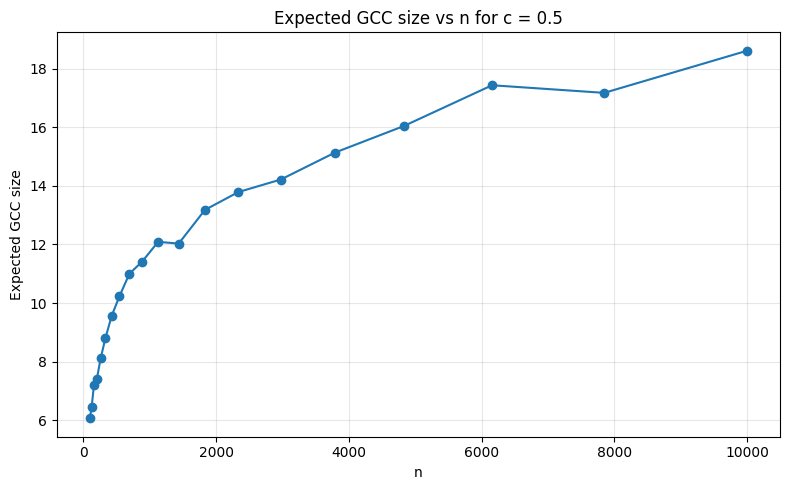

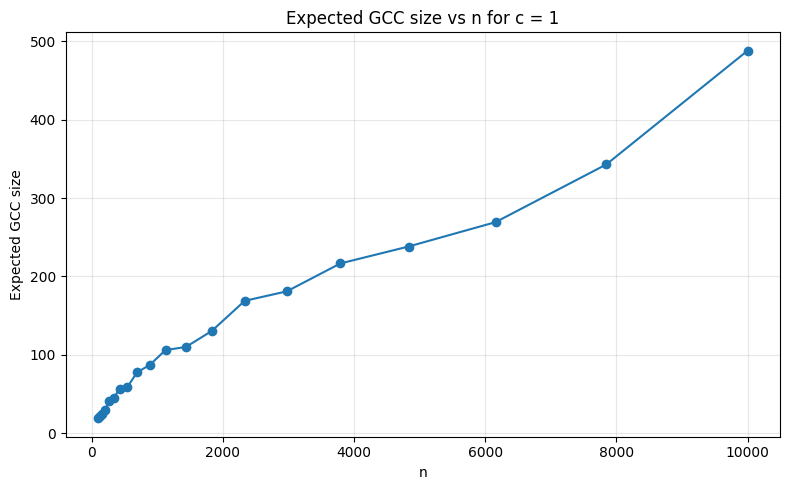

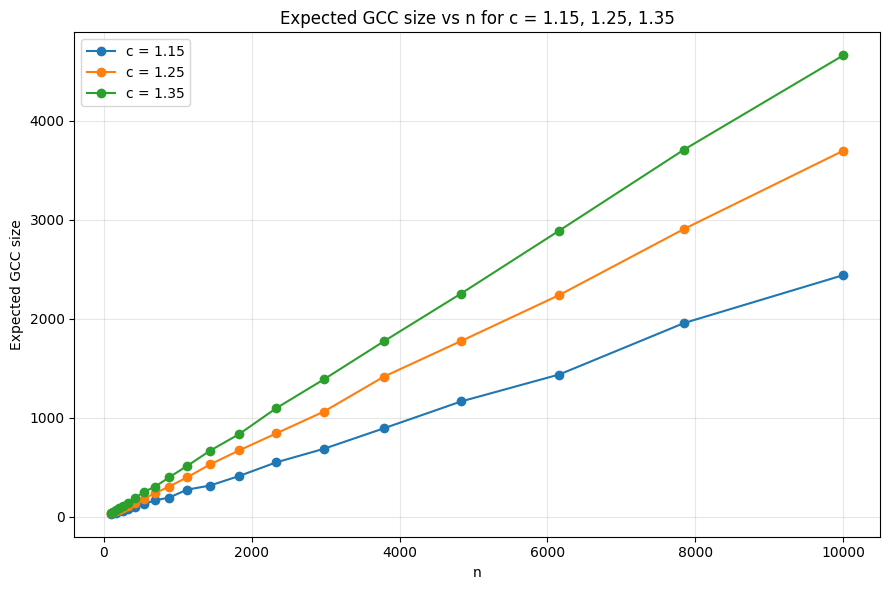

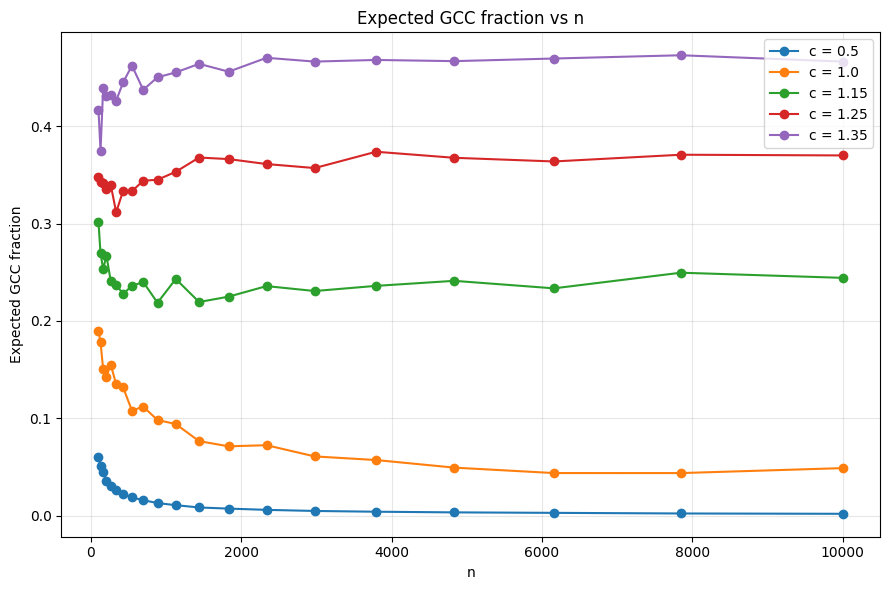


Results for c = 0.5
    n        p  expected_gcc_size  expected_gcc_fraction
  100 0.005000               6.06               0.060600
  127 0.003937               6.46               0.050866
  162 0.003086               7.21               0.044506
  206 0.002427               7.42               0.036019
  263 0.001901               8.12               0.030875
  335 0.001493               8.81               0.026299
  428 0.001168               9.56               0.022336
  545 0.000917              10.23               0.018771
  695 0.000719              11.00               0.015827
  885 0.000565              11.41               0.012893
 1128 0.000443              12.09               0.010718
 1438 0.000348              12.03               0.008366
 1832 0.000273              13.18               0.007194
 2335 0.000214              13.79               0.005906
 2976 0.000168              14.22               0.004778
 3792 0.000132              15.14               0.003993
 4832 0.00

In [12]:
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

np.random.seed(42)
random.seed(42)

n_values = np.unique(np.logspace(np.log10(100), np.log10(10000), 20, dtype=int))

num_trials = 100

c_values_single = [0.5, 1.0]
c_values_multi = [1.15, 1.25, 1.35]


def estimate_expected_gcc_size(n, c, num_trials=100, seed_start=0):
    p = c / n
    gcc_sizes = []

    for t in range(num_trials):
        random.seed(seed_start + t)

        g = ig.Graph.Erdos_Renyi(
            n=n,
            p=p,
            directed=False,
            loops=False
        )

        if g.ecount() == 0:
            gcc_size = 1
        else:
            gcc_size = max(g.components().sizes())

        gcc_sizes.append(gcc_size)

    gcc_sizes = np.array(gcc_sizes)
    return gcc_sizes.mean(), gcc_sizes.std(), (gcc_sizes / n).mean()


records = []
seed_counter = 1000

for c in [0.5, 1.0] + c_values_multi:
    for n in n_values:
        mean_gcc, std_gcc, mean_gcc_frac = estimate_expected_gcc_size(
            n=n,
            c=c,
            num_trials=num_trials,
            seed_start=seed_counter
        )
        seed_counter += num_trials

        records.append({
            "c": c,
            "n": n,
            "p": c / n,
            "expected_gcc_size": mean_gcc,
            "std_gcc_size": std_gcc,
            "expected_gcc_fraction": mean_gcc_frac
        })

df = pd.DataFrame(records)

# c = 0.5
df_c05 = df[df["c"] == 0.5]

plt.figure(figsize=(8, 5))
plt.plot(df_c05["n"], df_c05["expected_gcc_size"], marker='o')
plt.xlabel("n")
plt.ylabel("Expected GCC size")
plt.title("Expected GCC size vs n for c = 0.5")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# c = 1
df_c1 = df[df["c"] == 1.0]

plt.figure(figsize=(8, 5))
plt.plot(df_c1["n"], df_c1["expected_gcc_size"], marker='o')
plt.xlabel("n")
plt.ylabel("Expected GCC size")
plt.title("Expected GCC size vs n for c = 1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# c = 1.15, 1.25, 1.35
plt.figure(figsize=(9, 6))
for c in c_values_multi:
    temp = df[df["c"] == c]
    plt.plot(temp["n"], temp["expected_gcc_size"], marker='o', label=f"c = {c}")

plt.xlabel("n")
plt.ylabel("Expected GCC size")
plt.title("Expected GCC size vs n for c = 1.15, 1.25, 1.35")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# GCC fraction
plt.figure(figsize=(9, 6))
for c in [0.5, 1.0, 1.15, 1.25, 1.35]:
    temp = df[df["c"] == c]
    plt.plot(temp["n"], temp["expected_gcc_fraction"], marker='o', label=f"c = {c}")

plt.xlabel("n")
plt.ylabel("Expected GCC fraction")
plt.title("Expected GCC fraction vs n")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nResults for c = 0.5")
print(df[df["c"] == 0.5][["n", "p", "expected_gcc_size", "expected_gcc_fraction"]].to_string(index=False))

print("\nResults for c = 1")
print(df[df["c"] == 1.0][["n", "p", "expected_gcc_size", "expected_gcc_fraction"]].to_string(index=False))

print("\nResults for c = 1.15, 1.25, 1.35")
print(df[df["c"].isin(c_values_multi)][["c", "n", "p", "expected_gcc_size", "expected_gcc_fraction"]].to_string(index=False))

Explanation

For c = 0.5 (< 1), the expected GCC size increases only slowly as n grows, while the GCC fraction keeps decreasing toward 0. This means no giant connected component forms, and the growth is approximately logarithmic.

For c = 1, the GCC size grows faster than the subcritical case, but the fraction still decreases toward 0. This is the critical point, where the GCC scales approximately as n^(2/3).

For c = 1.15, 1.25, and 1.35 (> 1), the expected GCC size increases approximately linearly with n, and the GCC fraction remains roughly constant:
about 0.24 for c = 1.15,
about 0.36 for c = 1.25,
about 0.46 for c = 1.35.

This shows that when c > 1, a giant connected component exists and occupies a positive fraction of the network.

Therefore, the relation between GCC size and n is:

c < 1: grows slowly, approximately log(n)
c = 1: approximately n^(2/3)
c > 1: approximately linear in n